In [244]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [245]:
df = pd.read_csv('./data/merged_data.csv')

In [246]:
cols = ['order_id','order_purchase_timestamp','order_approved_at','order_delivered_carrier_date',
         'order_delivered_customer_date','order_estimated_delivery_date','customer_city','customer_state',
         'shipping_limit_date','review_score','product_category_name_english','seller_city','seller_state']
df2 = df[cols].copy()

In [247]:
# 파생 컬럼 생성
df2['order_purchase_timestamp'] = pd.to_datetime(df2['order_purchase_timestamp'])
df2['order_delivered_customer_date'] = pd.to_datetime(df2['order_delivered_customer_date'])
df2['order_estimated_delivery_date'] = pd.to_datetime(df2['order_estimated_delivery_date'])
df2['order_approved_at'] = pd.to_datetime(df2['order_approved_at'])
df2['order_delivered_carrier_date'] = pd.to_datetime(df2['order_delivered_carrier_date'])

# 주문 시점의 요일 정보 추가
df2['order_purchase_dayofweek'] = df2['order_purchase_timestamp'].dt.dayofweek
df2['order_purchase_dayofweek'] = df2['order_purchase_dayofweek'].map({
0: 'monday',
1: 'tuesday',
2: 'wednesday',
3: 'thursday',
4: 'friday',
5: 'saturday',
6: 'sunday'
})
# 요일 순서 정의 
weekday_order = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']

# 데이터를 범주형(Categorical)으로 변환하여 순서 부여
# 이렇게 하면 groupby를 해도 이 순서가 유지됨
df2['order_purchase_dayofweek'] = pd.Categorical(df2['order_purchase_dayofweek'], 
                                                categories=weekday_order, 
                                                ordered=True)

# 주문 시점의 월 정보 추가
df2['order_purchase_month'] = df2['order_purchase_timestamp'].dt.month
df2['order_purchase_month'] = df2['order_purchase_month'].astype('category')
df2['order_purchase_month'] = df2['order_purchase_month'].cat.set_categories([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], ordered=True)
df2['order_purchase_month'] = df2['order_purchase_month'].cat.codes
df2['order_purchase_month'] = df2['order_purchase_month'].astype(int)
df2['order_purchase_month'] = df2['order_purchase_month'].map({
0: 1,
1: 2,
2: 3,
3: 4,
4: 5,
5: 6,
6: 7,
7: 8,
8: 9,
9: 10,
10: 11,
11: 12
})
df2['order_purchase_month'] = df2['order_purchase_month'].astype(int)

# 주문 시점의 연도 정보 추가
df2['order_purchase_year'] = df2['order_purchase_timestamp'].dt.year
df2['order_purchase_year'] = df2['order_purchase_year'].astype(int)

df2.info()
df2.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 96432 entries, 0 to 96431
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96432 non-null  str           
 1   order_purchase_timestamp       96432 non-null  datetime64[us]
 2   order_approved_at              96432 non-null  datetime64[us]
 3   order_delivered_carrier_date   96432 non-null  datetime64[us]
 4   order_delivered_customer_date  96432 non-null  datetime64[us]
 5   order_estimated_delivery_date  96432 non-null  datetime64[us]
 6   customer_city                  96432 non-null  str           
 7   customer_state                 96432 non-null  str           
 8   shipping_limit_date            96432 non-null  str           
 9   review_score                   95786 non-null  float64       
 10  product_category_name_english  95053 non-null  str           
 11  seller_city               

,order_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,shipping_limit_date,review_score,product_category_name_english,seller_city,seller_state,order_purchase_dayofweek,order_purchase_month,order_purchase_year
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,sao paulo,SP,2017-10-06 11:07:15,4.0,housewares,maua,SP,monday,10,2017
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,barreiras,BA,2018-07-30 03:24:27,4.0,perfumery,belo horizonte,SP,tuesday,7,2018
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,vianopolis,GO,2018-08-13 08:55:23,5.0,auto,guariba,SP,wednesday,8,2018
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,sao goncalo do amarante,RN,2017-11-23 19:45:59,5.0,pet_shop,belo horizonte,MG,saturday,11,2017
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,santo andre,SP,2018-02-19 20:31:37,5.0,stationery,mogi das cruzes,SP,tuesday,2,2018
5,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,congonhinhas,PR,2017-07-13 22:10:13,4.0,auto,guarulhos,SP,sunday,7,2017
6,6514b8ad8028c9f2cc2374ded245783f,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,nilopolis,RJ,2017-05-22 13:22:11,5.0,auto,atibaia,SP,tuesday,5,2017
7,76c6e866289321a7c93b82b54852dc33,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,faxinalzinho,RS,2017-01-27 18:29:09,1.0,furniture_decor,sao jose do rio pardo,SP,monday,1,2017
8,e69bfb5eb88e0ed6a785585b27e16dbf,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23,sorocaba,SP,2017-08-11 12:05:32,5.0,office_furniture,itaquaquecetuba,SP,saturday,7,2017
9,e6ce16cb79ec1d90b1da9085a6118aeb,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07,rio de janeiro,RJ,2017-05-22 19:50:18,1.0,garden_tools,cariacica,ES,tuesday,5,2017


In [248]:
### 실제 배송 소요 일수 계산 (order_delivered_customer_date - order_purchase_timestamp)
df2['delivery_days'] = (df2['order_delivered_customer_date'] - df2['order_purchase_timestamp']).dt.total_seconds() / 86400
df2['delivery_days'] = df2['delivery_days'].astype(int)

### 출고 소요 일수 계산 (order_delivered_carrier_date - order_purchase_timestamp)
df2['dispatch_days'] = (df2['order_delivered_carrier_date'] - df2['order_purchase_timestamp']).dt.total_seconds() / 86400
df2['dispatch_days'] = df2['dispatch_days'].astype(int)

### 승인 소요 일수 계산 (order_approved_at - order_purchase_timestamp)
df2['approved_days'] = (df2['order_approved_at'] - df2['order_purchase_timestamp']).dt.total_seconds() / 86400
df2['approved_days'] = df2['approved_days'].astype(int)

### 예상 배송 소요 일수 계산 (order_estimated_delivery_date - order_purchase_timestamp)
df2['expected_delivery_days'] = (df2['order_estimated_delivery_date'] - df2['order_purchase_timestamp']).dt.total_seconds() / 86400
df2['expected_delivery_days'] = df2['expected_delivery_days'].astype(int)

### 배송 오류 일수 계산 (order_delivered_customer_date - order_estimated_delivery_date)
df2['delay_days'] = (df2['order_delivered_customer_date'] - df2['order_estimated_delivery_date']).dt.total_seconds() / 86400
df2['delay_days'] = df2['delay_days'].astype(int)

In [249]:
df2.head()

,order_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,shipping_limit_date,review_score,product_category_name_english,seller_city,seller_state,order_purchase_dayofweek,order_purchase_month,order_purchase_year,delivery_days,dispatch_days,approved_days,expected_delivery_days,delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,sao paulo,SP,2017-10-06 11:07:15,4.0,housewares,maua,SP,monday,10,2017,8,2,0,15,-7
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,barreiras,BA,2018-07-30 03:24:27,4.0,perfumery,belo horizonte,SP,tuesday,7,2018,13,1,1,19,-5
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,vianopolis,GO,2018-08-13 08:55:23,5.0,auto,guariba,SP,wednesday,8,2018,9,0,0,26,-17
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,sao goncalo do amarante,RN,2017-11-23 19:45:59,5.0,pet_shop,belo horizonte,MG,saturday,11,2017,13,3,0,26,-12
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,santo andre,SP,2018-02-19 20:31:37,5.0,stationery,mogi das cruzes,SP,tuesday,2,2018,2,0,0,12,-9


In [250]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 96432 entries, 0 to 96431
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96432 non-null  str           
 1   order_purchase_timestamp       96432 non-null  datetime64[us]
 2   order_approved_at              96432 non-null  datetime64[us]
 3   order_delivered_carrier_date   96432 non-null  datetime64[us]
 4   order_delivered_customer_date  96432 non-null  datetime64[us]
 5   order_estimated_delivery_date  96432 non-null  datetime64[us]
 6   customer_city                  96432 non-null  str           
 7   customer_state                 96432 non-null  str           
 8   shipping_limit_date            96432 non-null  str           
 9   review_score                   95786 non-null  float64       
 10  product_category_name_english  95053 non-null  str           
 11  seller_city               

In [251]:
df2.isna().sum()

order_id                            0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date        0
order_delivered_customer_date       0
order_estimated_delivery_date       0
customer_city                       0
customer_state                      0
shipping_limit_date                 0
review_score                      646
product_category_name_english    1379
seller_city                         0
seller_state                        0
order_purchase_dayofweek            0
order_purchase_month                0
order_purchase_year                 0
delivery_days                       0
dispatch_days                       0
approved_days                       0
expected_delivery_days              0
delay_days                          0
dtype: int64

In [252]:
# review_score 컬럼 결측치 제거
print(f"제거 전 데이터 개수: {len(df2)}")
df2 = df2.dropna(subset=['review_score']).reset_index()
print(f"제거 후 데이터 개수: {len(df2)}")

제거 전 데이터 개수: 96432
제거 후 데이터 개수: 95786


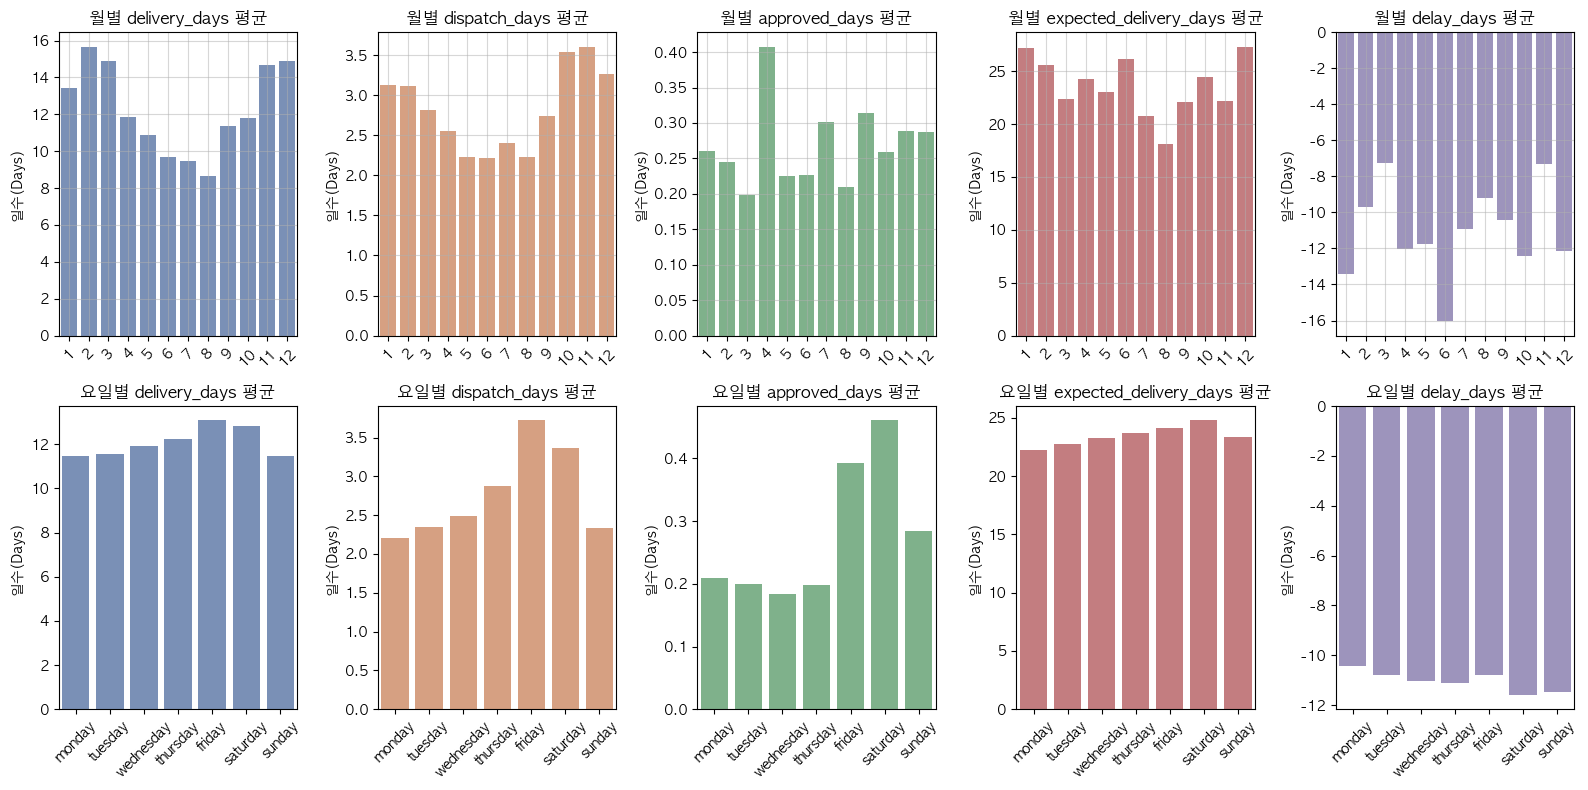

In [253]:
# 월별, 요일별 배송 소요 일수 

# 2x4 서브플롯 생성
fig, axes = plt.subplots(2, 5, figsize=(16, 8))

days = ['delivery_days','dispatch_days','approved_days','expected_delivery_days','delay_days']
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

for i, day in enumerate(days):
    ax1 = axes[0][i]
    ax2 = axes[1][i]

    monthly = df2.groupby('order_purchase_month')[day].mean().reset_index()
    daily = df2.groupby('order_purchase_dayofweek')[day].mean().reset_index()

    # 월별 막대 그래프
    sns.barplot(data=monthly, x='order_purchase_month', y=day,
                ax=ax1, color=colors[i], alpha=0.8)
    
    # 요일별 막대 그래프
    sns.barplot(data=daily, x='order_purchase_dayofweek', y=day,
                ax=ax2, color=colors[i], alpha=0.8)
    
    # 타이틀 및 라벨 설정
    ax1.set_title(f"월별 {day} 평균")
    ax2.set_title(f"요일별 {day} 평균")
    ax1.grid(alpha=0.5)
    for ax in [ax1, ax2]:
        ax.set_xlabel("") # x라벨 중복 제거
        ax.set_ylabel("일수(Days)")
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


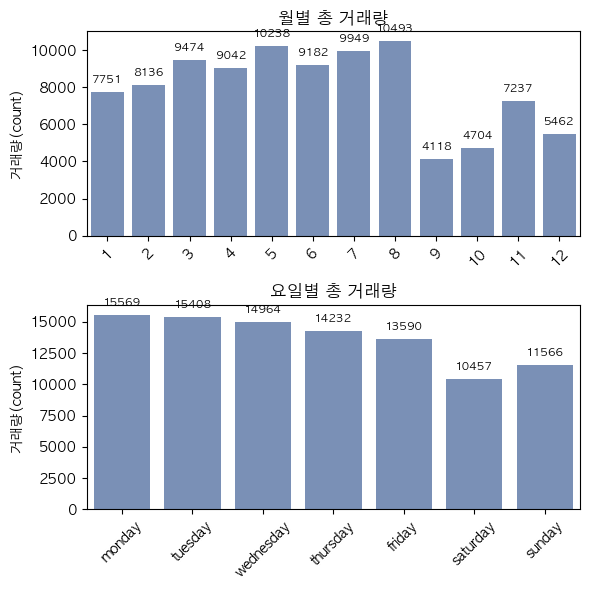

In [254]:
# 월별 거래량

fig, axes = plt.subplots(2, 1, figsize=(6, 6))

monthly = df2.groupby('order_purchase_month').size().reset_index(name='count')
daily = df2.groupby('order_purchase_dayofweek').size().reset_index(name='count')

# 월별 막대 그래프
sns.barplot(data=monthly, x='order_purchase_month', y='count', 
            ax=axes[0], color="#4C72B0", alpha=0.8)
axes[0].set_title(f"월별 총 거래량")
    
# 요일별 막대 그래프
sns.barplot(data=daily, x='order_purchase_dayofweek', y='count',
                ax=axes[1], color="#4C72B0", alpha=0.8)
axes[1].set_title(f"요일별 총 거래량")
    
for ax in [axes[0], axes[1]]:
    ax.set_xlabel("")
    ax.set_ylabel("거래량(count)")
    ax.tick_params(axis='x', rotation=45)
# 막대 상단에 숫자 표시 (선택 사항)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points', fontsize=8)

plt.tight_layout()
plt.show()

Carnival (Feb 14-17), New Year's Day (Jan 1), Independence Day (Sept 7), and Christmas (Dec 25)

- 월별로 배송에 걸리는 일수 (delivery_days : Delivered - Purchase) 를 확인했을 때 1,2,3,11,12월에 배송소요일이 크게 나오고, 6,7,8월에 배송소요일이 적게 나온다
- 이는 계절성과 관련이 있지않을까?
- 월별 거래량을 확인했을 때에도 오히려 배송소요일이 크게 나온 달보다 배송소요일이 적게 나온 달의 월별 거래량이 크게 나왔기 때문에 거래량으로 인한 배송지연은 아니라고 보여진다
- 브라질은 가톨릭 신자가 많아 크리스마스에 성대한 기념 행사가 일어나는데 이와 관련하여 12월에 배송지연이 많이 발생하는것 아닐까?
- 또한 2월 즈음에도 '카니발'이라는 중요한 축제도 열리기 때문에 이러한 연휴가 주로 껴있는 연말,연초에 배송이 오래 걸리고 이는 결국 거래량과는 무관하다고 보여진다

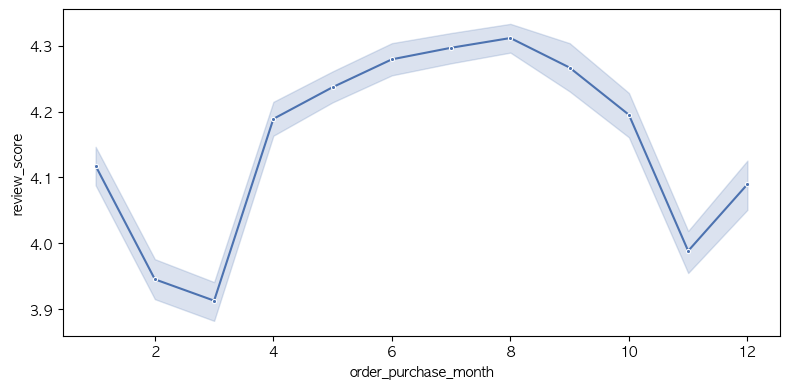

In [255]:
# 월별 리뷰스코어 변화 -- 선그래프 
plt.figure(figsize=(8,4))
sns.lineplot(data=df2, x='order_purchase_month', y='review_score', 
                 color="#4C72B0", marker='o', markersize=3, errorbar=('ci', 95))
plt.tight_layout()
plt.show()

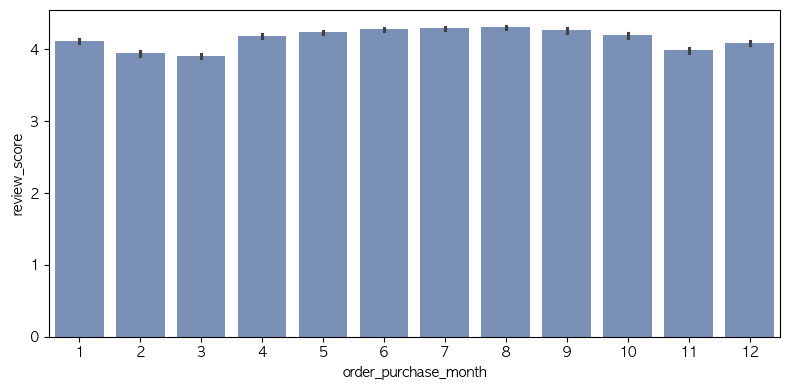

In [256]:
# 월별 리뷰스코어 변화 -- 막대그래프 
plt.figure(figsize=(8,4))
sns.barplot(data=df2, x='order_purchase_month', y='review_score', 
                 color="#4C72B0", alpha=0.8)
plt.tight_layout()
plt.show()

월별 delivery_days가 차이가 나서 이에 따른 월별 review_score 또한 특징적인 추이가 나타날까 궁금하여 lineplot과 barplot을 그려보았지만, 

사실상 눈에 띄는 변화는 보이지 않았음

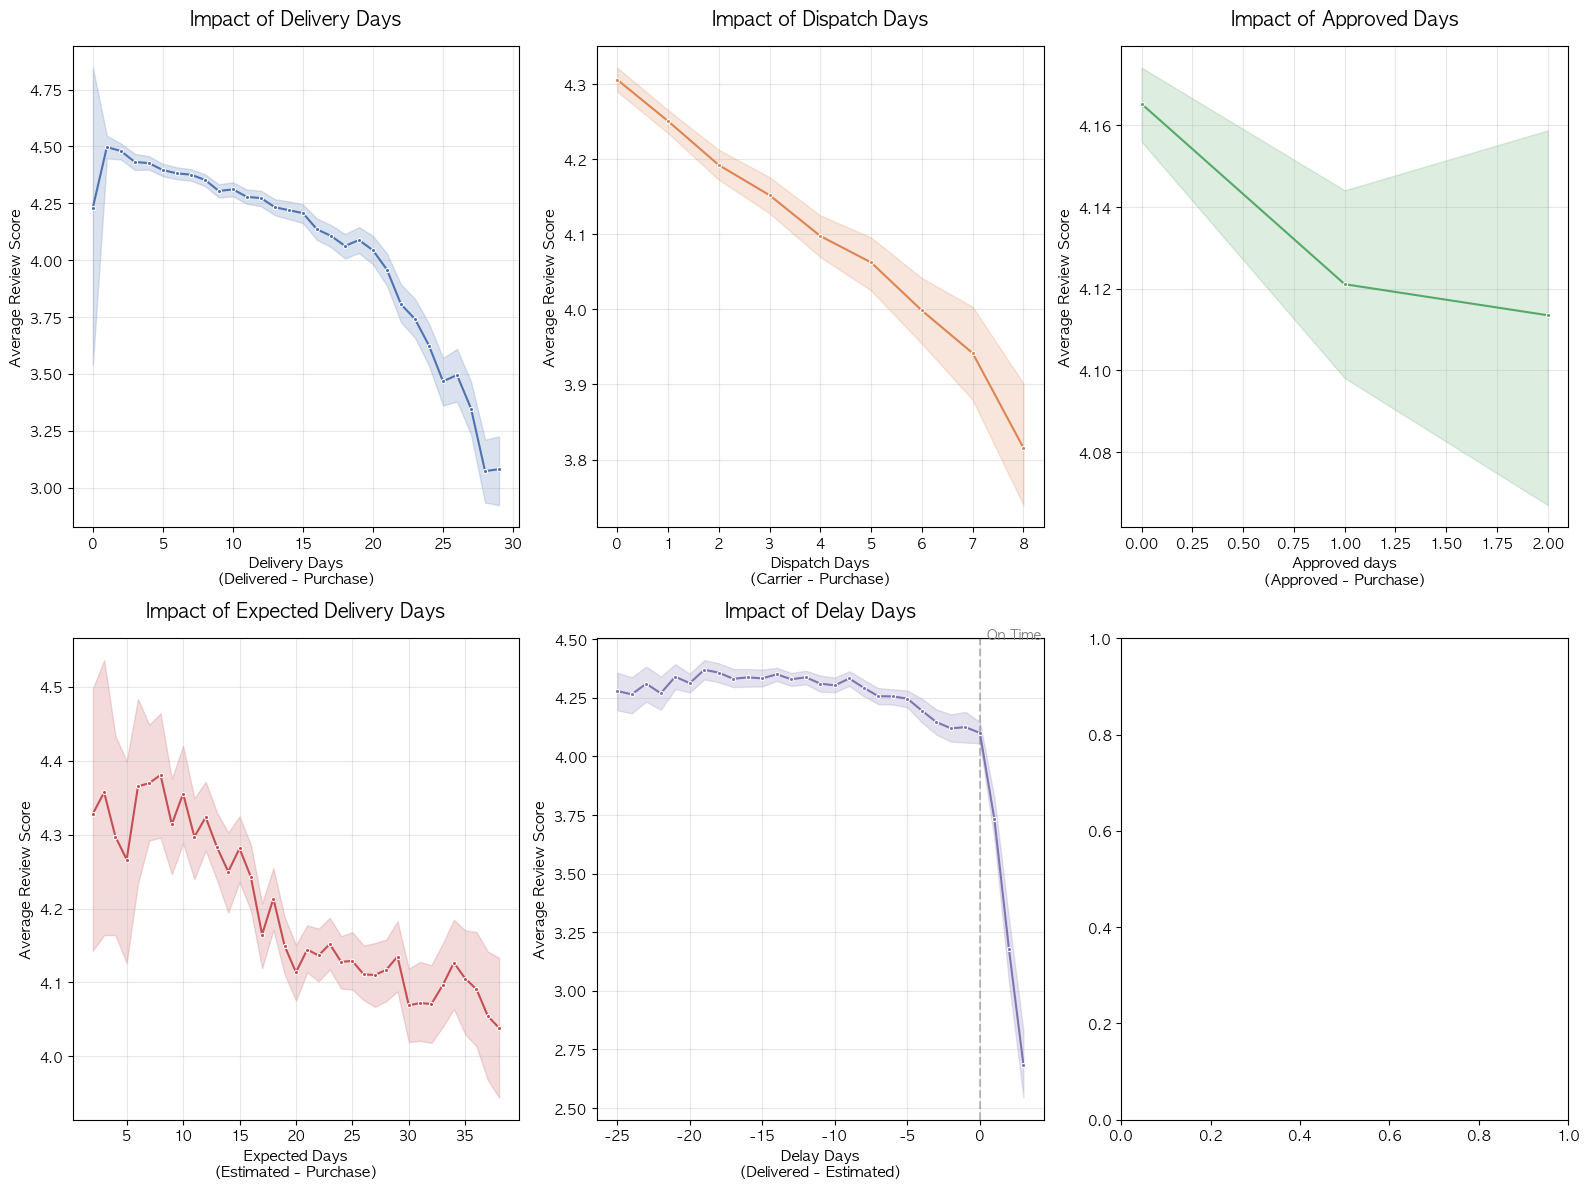

In [257]:
# 배송 소요 일수에 따른 리뷰 스코어 변화

# 1. 시각화 대상 컬럼과 수식 정의
plot_info = [
    {'col': 'delivery_days', 'label': 'Delivery Days\n(Delivered - Purchase)', 'color': '#4C72B0'},
    {'col': 'dispatch_days', 'label': 'Dispatch Days\n(Carrier - Purchase)', 'color': '#DD8452'},
    {'col': 'approved_days', 'label': 'Approved days\n(Approved - Purchase)', 'color': '#55A868'},
    {'col': 'expected_delivery_days', 'label': 'Expected Days\n(Estimated - Purchase)', 'color': '#C44E52'},
    {'col': 'delay_days', 'label': 'Delay Days\n(Delivered - Estimated)', 'color': '#8172B3'}
]

# 2. 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 3, figsize=(16, 12))
axes = axes.flatten()

for i, info in enumerate(plot_info):
    col = info['col']
   
    # 너무 적은 샘플(롱테일)로 인한 왜곡 방지를 위해 상위 95% 구간까지만 시각화 (이상치 제외)
    upper_limit = df2[col].quantile(0.95)
    lower_limit = df2[col].quantile(0.05) if col == 'delay_days' else 0
    plot_data = df2[(df2[col] >= lower_limit) & (df2[col] <= upper_limit)]
    
    # 일수별 평균 리뷰 점수 시각화 (신뢰구간 포함)
    sns.lineplot(data=plot_data, x=col, y='review_score', 
                 ax=axes[i], color=info['color'], marker='o', markersize=3, errorbar=('ci', 95))
    
    # 타이틀 및 축 라벨 설정 (수식 포함)
    axes[i].set_title(f"Impact of {col.replace('_', ' ').title()}", fontsize=14, fontweight='bold', pad=15)
    axes[i].set_xlabel(info['label'], fontsize=11, fontweight='semibold')
    axes[i].set_ylabel("Average Review Score", fontsize=11)
    axes[i].grid(True, alpha=0.3)
    
    # 0점 기준선 (delivery_error_days의 경우 지연 여부 판단 기준)
    if col == 'delay_days':
        axes[i].axvline(0, color='gray', linestyle='--', alpha=0.5)
        axes[i].text(0.5, 4.5, 'On Time', color='gray', fontsize=10)

plt.tight_layout()
plt.show()


확실히 배송소요일이 오래 걸리거나 지연이 발생하면 리뷰스코어에 크게 타격이 있는 것으로 보여짐

(delivery_days & delay_days 그래프 확인)

따라서 상관관계를 파악해보기로 함

[delivery_days]
- 스피어만 상관계수: -0.235
- 유의성(P-value): 0.0000e+00
- 해석: 약한 정도의 음의 상관관계

[dispatch_days]
- 스피어만 상관계수: -0.108
- 유의성(P-value): 1.3446e-244
- 해석: 약한 정도의 음의 상관관계

[approved_days]
- 스피어만 상관계수: -0.015
- 유의성(P-value): 4.4791e-06
- 해석: 약한 정도의 음의 상관관계

[expected_delivery_days]
- 스피어만 상관계수: -0.056
- 유의성(P-value): 1.1826e-67
- 해석: 약한 정도의 음의 상관관계

[delay_days]
- 스피어만 상관계수: -0.177
- 유의성(P-value): 0.0000e+00
- 해석: 약한 정도의 음의 상관관계



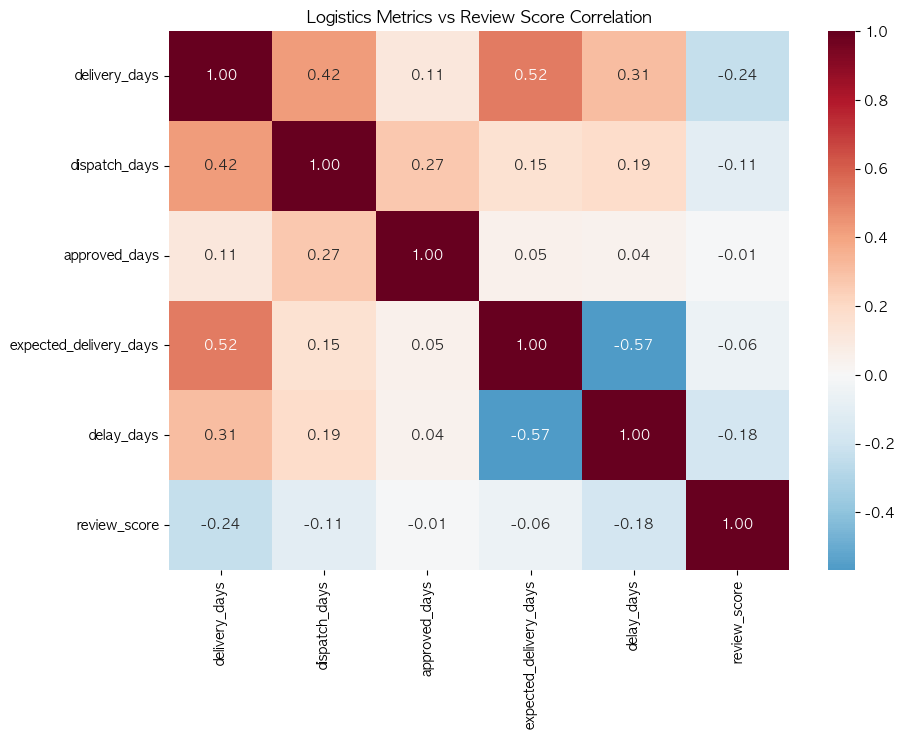

In [258]:
# 배송 소요 일수 포함 주요 일수 컬럼과 리뷰 스코어의 상관관계

# 피어슨은 선형관계를 측정하는데 현 데이터는 선형성을 측정하는 것이 적절하지 않음
# '경향성'을 파악하고 범주형(순서형) 데이터의 rank를 측정할 땐 스피어만이 더 적절함

# 1. 상관관계 분석 대상에서 타겟 변수 분리
features = ['delivery_days', 'dispatch_days', 'approved_days', 'expected_delivery_days', 'delay_days']
target = 'review_score'

for day in features:
    valid_df = df2[[day, target]]
    
    if not valid_df.empty:
        # Spearman 산출 및 P-value 검정
        corr, p_value = stats.spearmanr(valid_df[day], valid_df[target])
        
        print(f"[{day}]")
        print(f"- 스피어만 상관계수: {corr:.3f}")
        print(f"- 유의성(P-value): {p_value:.4e}")
        
        # 해석 가이드 추가
        strength = "강한" if abs(corr) > 0.5 else "중간" if abs(corr) > 0.3 else "약한"
        sign = "음" if corr < 0 else "양" 
        print(f"- 해석: {strength} 정도의 {sign}의 상관관계\n")

# 3. 히트맵 시각화 (타겟 변수를 포함하되 보기 좋게 정렬)
plt.figure(figsize=(10, 7))
sns.heatmap(df2[features + [target]].corr(method='spearman'), 
            annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title("Logistics Metrics vs Review Score Correlation")
plt.show()

[delivery_days] -0.235

[dispatch_days] -0.108

[approved_days] -0.015

[expected_delivery_days] -0.056

[delay_days] -0.177

- 배송 소요일(delivery_days)은 review score와의 상관관계를 측정해보았을 때 -0.235로 약한 정도의 음의 상관관계를 보였다 
- 또한 지연일이나 출고를 하는데까지 걸린 시간보다 배송소요일 자체가 review score와 조금 더 강한 상관관계를 보임을 알 수 있다
- 이는 지연이 얼마나 되었는지나, 출고될 때까지 걸린 시간보다는 배송에 얼마나 소요되었는지가 더 영향력이 강함을 나타낸다

In [259]:
# 1. 지연 여부 변수 생성 (Binary)
# 지연된 경우(delay days > 0)와 정시/조기 도착한 경우 비교
df2['is_delayed'] = df2['delay_days'] > 0

# 2. 지연 여부에 따른 평균 리뷰 점수 차이 확인 (T-test 혹은 Mann-Whitney U test)
delay_group = df2[df2['is_delayed'] == True]['review_score']
ontime_group = df2[df2['is_delayed'] == False]['review_score']

u_stat, p_val = stats.mannwhitneyu(delay_group, ontime_group)
print(f"지연 그룹 평균 점수: {delay_group.mean():.2f}")
print(f"정시/조기 그룹 평균 점수: {ontime_group.mean():.2f}")
print(f"집단 간 차이 유의성 (p-value): {p_val:.4e}")

지연 그룹 평균 점수: 2.27
정시/조기 그룹 평균 점수: 4.29
집단 간 차이 유의성 (p-value): 0.0000e+00


위에서 지연이 얼마나 되었는지보다 배송소요일이 review score에 더 강한 음의 상관관계를 보인다고 했는데 

그렇다면 지연이 되었는지의 여부 자체가 review score에 부정적인 영향을 끼치는지 확인해보고자 하였다.

In [260]:
# 1. 온타임 그룹 정의 (delay_days <= 0)
df_ontime = df2[df2['delay_days'] <= 0].copy()

# 2. 온타임 그룹 내에서 배송 소요 일수의 중앙값 산출
# 중앙값을 기준으로 하면 데이터의 치우침(Skewness)에 강건한 기준을 세울 수 있습니다.
ontime_duration_median = df_ontime['delivery_days'].median()
print(f"온타임 그룹의 배송 소요일 중앙값: {ontime_duration_median:.1f}일")

# 3. 세 세부 그룹 생성
# 그룹 1: 정시에 도착했고, 절대적 속도도 빠른 경우
ontime_fast = df_ontime[df_ontime['delivery_days'] <= ontime_duration_median]['review_score']

# 그룹 2: 정시에 도착했으나, 절대적 속도는 느린 경우 (약속은 지켰지만 오래 기다림)
ontime_slow = df_ontime[df_ontime['delivery_days'] > ontime_duration_median]['review_score']

# 그룹 3: 약속된 날짜보다 늦게 도착한 경우 (지연)
delayed_group = df2[df2['delay_days'] > 0]['review_score']

# 4. 결과 출력
print("-" * 30)
print(f"1. 정시-신속 그룹 평균 점수: {ontime_fast.mean():.2f} (n={len(ontime_fast)})")
print(f"2. 정시-저속 그룹 평균 점수: {ontime_slow.mean():.2f} (n={len(ontime_slow)})")
print(f"3. 배송 지연 그룹 평균 점수: {delayed_group.mean():.2f} (n={len(delayed_group)})")

# 5. 통계적 유의성 확인 (Kruskal-Wallis 검정: 세 집단 이상의 평균 차이 확인)
from scipy.stats import kruskal
stat, p_val = kruskal(ontime_fast, ontime_slow, delayed_group)
print(f"\n세 집단 간 차이 유의성 (p-value): {p_val:.4e}")

온타임 그룹의 배송 소요일 중앙값: 9.0일
------------------------------
1. 정시-신속 그룹 평균 점수: 4.39 (n=46067)
2. 정시-저속 그룹 평균 점수: 4.19 (n=43339)
3. 배송 지연 그룹 평균 점수: 2.27 (n=6380)

세 집단 간 차이 유의성 (p-value): 0.0000e+00


정시에 배송완료가 되었더라도 배송소요일의 평균보다 늦은 경우라면 리뷰 스코어는 낮지 않을까하여

세 그룹으로 나누어 리뷰스코어를 확인하였다

결론은 신속한 정시 도착 그룹보다 평균점수가 낮긴 하지만, 배송지연된 그룹보다는 여전히 약 1.85배 높았다

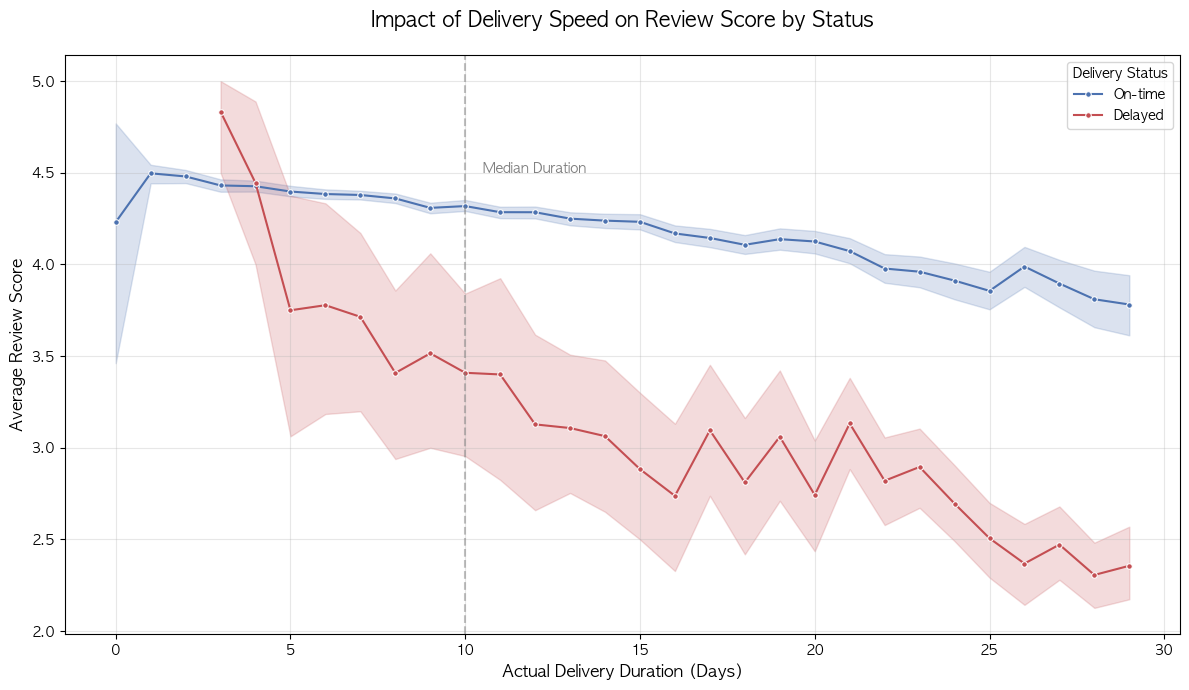

In [261]:
# 1. 시각화 데이터 준비 (이상치 제거 - 상위 95% 수준)
upper_limit = df2['delivery_days'].quantile(0.95)
plot_data = df2[df2['delivery_days'] <= upper_limit].copy()

# 2. 범례(Legend)를 위한 지연 여부 라벨링
plot_data['status'] = plot_data['is_delayed'].map({True: 'Delayed', False: 'On-time'})

# 3. 시각화
plt.figure(figsize=(12, 7))
sns.lineplot(data=plot_data, x='delivery_days', y='review_score', 
             hue='status', palette=['#4C72B0', '#C44E52'], 
             marker='o', markersize=4, errorbar=('ci', 95))

# 4. 그래프 디테일 설정
plt.title("Impact of Delivery Speed on Review Score by Status", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Actual Delivery Duration (Days)", fontsize=12)
plt.ylabel("Average Review Score", fontsize=12)
plt.legend(title="Delivery Status", frameon=True)
plt.grid(True, alpha=0.3)

# 5. 인사이트 강화를 위한 수직선 (예: 전체 평균 소요일)
plt.axvline(df2['delivery_days'].median(), color='gray', linestyle='--', alpha=0.5)
plt.text(df2['delivery_days'].median() + 0.5, 4.5, 'Median Duration', color='gray', fontsize=10)

plt.tight_layout()
plt.show()

지연된 그룹과 정시에 도착한 그룹 두가지로 나누어 실제 배송소요일에 따른 리뷰스코어 변화를 확인해보았다

지연된 그룹에서는 실제 배송소요일이 중앙값보다 적었음에도, 정시에 도착한 그룹보다 일찍 도착했음에도 이와는 상관없이 리뷰 스코어가 낮게 나온 것을 볼 수 있다

이를 통해 브라질 Olist 입점 판매자들은 예상도착일(estimated)을 고의적으로라도 넉넉하게 잡아서 혹시나 발생할 수도 있는 지연 문제를 예방하여야 한다

하지만 그 전에..
고객들은 예상배송소요일수가 길더라도 이는 리뷰 스코어에 영향을 미치지 않는지 확인해볼 필요가 있어보인다.

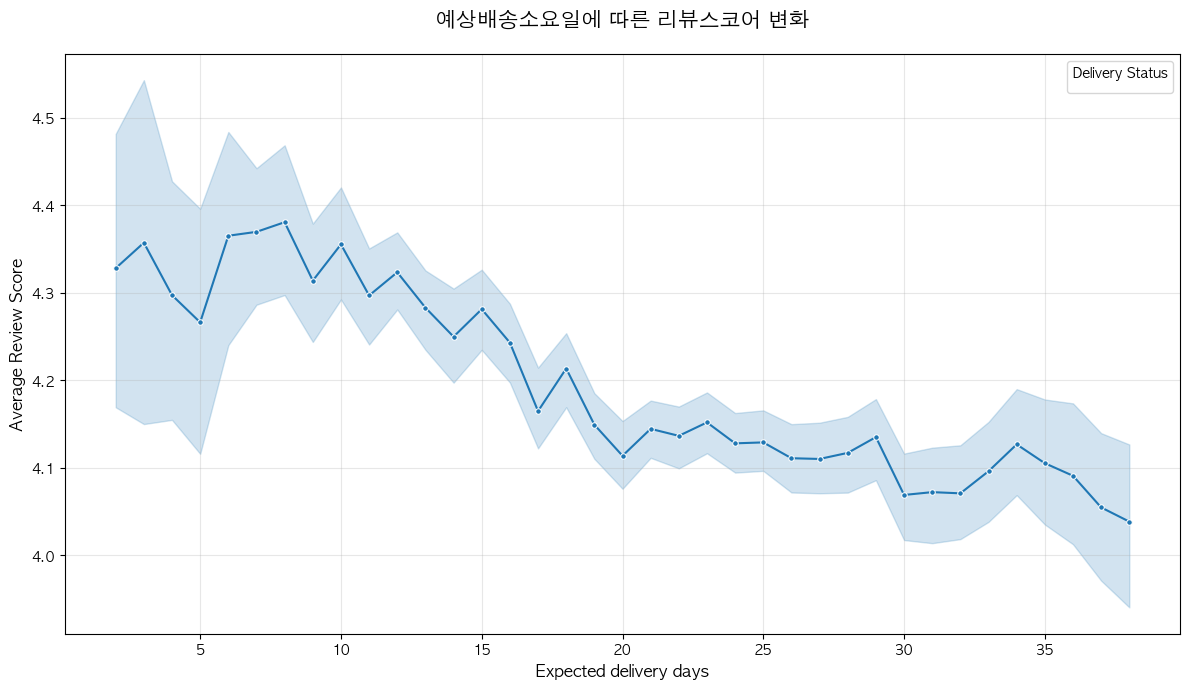

In [262]:
# 예상배송소요일(expected_delivery_days)에 따른 리뷰스코어 변화 추이 시각화
upper_limit = df2['expected_delivery_days'].quantile(0.95) # 이상치 제거 - 상위 95% 수준
plot_data = df2[df2['expected_delivery_days'] <= upper_limit].copy()

plt.figure(figsize=(12,7))
sns.lineplot(data=plot_data, x='expected_delivery_days', y='review_score', 
             marker='o', markersize=4, errorbar=('ci', 95))

plt.title("예상배송소요일에 따른 리뷰스코어 변화", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Expected delivery days", fontsize=12)
plt.ylabel("Average Review Score", fontsize=12)
plt.legend(title="Delivery Status", frameon=True)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

이에 따라 예상배송일을 길게 잡아도 이에 따른 리뷰스코어에 대한 영향은 크지 않다.

(위에서 구한 스피어만 상관계수를 확인하더라도 [expected_delivery_days] -0.056로 미미한 상관관계 수준)

지연이 발생하지 않도록 예상배송일을 의도적으로 길게 잡는 방법이 효과적일 것이다. (????)